In [1]:
from keras.api.layers import Input, Dense, Masking, LSTM, LayerNormalization, Embedding, Bidirectional
from keras.api.optimizers import Optimizer, Adam
from keras.api.models import Model, save_model
from keras.api.preprocessing.sequence import pad_sequences
from keras.api.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight
import sentencepiece as spm
import numpy as np
import numpy.typing as npt
import pandas as pd
import typing as tp
from pathlib import Path
from datetime import datetime as dt
from datetime import timedelta
import json

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE_PATH = Path('/content/drive/MyDrive/AI/GMAv2.5/')

In [4]:
class GMATrainer:
    def __init__(self):
        self.tokenizer: None|spm.SentencePieceProcessor = None
        self.X: None|npt.NDArray = None
        self.Y: None|npt.NDArray = None
        self.author_dictionary: dict[int, str] = {}
        self.class_weights: dict = {}
        self.model: None|Model = None
        self.history: tp.Any = None
        self.checkpoint_path: Path = Path()
        self.calculate_checkpoint_path()

    def calculate_checkpoint_path(self):
        now = dt.now() + timedelta(hours=3)
        suffix = now.strftime('%Y%m%d-%H%M%S')
        self.checkpoint_path: Path = Path(f'{BASE_PATH}/_checkpoints/checkpoint_{suffix}')

    def build_data(self, df: pd.DataFrame, tokenizer: spm.SentencePieceProcessor, maxlen: None|int=None):
        content = df['Content'].to_list()
        Y = df['NumericAuthor'].to_numpy()

        content = [tokenizer.EncodeAsIds(c) for c in content]
        content = pad_sequences(content, maxlen=maxlen, padding='pre', truncating='pre')
        X = np.array(content)

        author_dictionary = dict()
        for i in np.unique(Y):
            author = df[df['NumericAuthor'] == i]['Author'].iloc[0]
            author_dictionary[int(i)] = author

        self.X = X
        self.Y = Y
        self.author_dictionary = author_dictionary
        self.tokenizer = tokenizer
        cw = compute_class_weight('balanced', classes=np.unique(self.Y), y=self.Y)

        for i, w in enumerate(cw):
            self.class_weights[i] = w

    def build_model(self, lstm_units: int=128, embedding_dims: int=384, dense_layers=[64, 32]):
        num_classes = len(self.author_dictionary)

        x = i = Input(shape=(None,))
        x = Embedding(self.tokenizer.vocab_size(), embedding_dims)(x)
        x = Masking(mask_value=0)(x)
        x = Bidirectional(LSTM(lstm_units))(x)

        for dl in dense_layers:
            x = Dense(dl, activation='gelu')(x)
        x = Dense(num_classes, activation='softmax')(x)

        self.model = Model(i, x)


    def train_model(self, epochs: int=3, batch_size: int=32, optimizer: str|Optimizer='adam', test_size: float=0.2, save_checkpoints=True):
        assert self.model is not None
        self.calculate_checkpoint_path()
        self.model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        callbacks = []
        if save_checkpoints:
            self.checkpoint_path.mkdir(exist_ok=True, parents=True)
            callbacks.append(ModelCheckpoint(
                filepath=self.checkpoint_path / "checkpoint_epoch_{epoch:02d}_acc_{val_accuracy:.2f}.keras",
                monitor='val_accuracy',
            ))

        x_train, x_test, y_train, y_test = train_test_split(self.X, self.Y, test_size=test_size)
        self.history = self.model.fit(
            x_train, y_train, validation_data=(x_test, y_test),
            batch_size=batch_size, epochs=epochs, class_weight=self.class_weights,
            callbacks=callbacks
        )

    def save_model(self, model_name: str, tokenizer_name: str):
        assert self.model is not None
        assert self.X is not None

        model_file = f"{model_name}.keras"
        model_config = {
            'model_file': model_file,
            'tokenizer_name': tokenizer_name,
            'maxlen': int(self.X.shape[1]),
            'author_dictionary': self.author_dictionary,
        }

        model_path = Path(f"{BASE_PATH}/models/{model_name}")
        model_path.mkdir(exist_ok=True, parents=True)

        save_model(self.model, model_path/model_file)
        with open(model_path/'config.json', 'w') as f:
            json.dump(model_config, f)

        if self.checkpoint_path.exists():
            !mv {self.checkpoint_path} {self.checkpoint_path.parent/model_name}

In [5]:
tokenizer = spm.SentencePieceProcessor()
tokenizer.Load(f'{BASE_PATH}/tok4000.model')

df = pd.read_csv(f'{BASE_PATH}/esolangs_messages.csv')
trainer = GMATrainer()
trainer.build_data(df, tokenizer)
print(f"{trainer.Y.shape[0]} entries.")
print(f"Maxlen: {trainer.X.shape[1]}")

31062 entries.
Maxlen: 44


In [6]:
trainer.build_model(
    lstm_units=256,
    embedding_dims=256,
    dense_layers=[256, 128, 64, 32]
)

assert trainer.model is not None
trainer.model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │  1,024,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None, 256) │          0 │ embedding[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, None, 256) │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 512)       │  1,050,624 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 6)         │        198 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,249,382 (8.58 MB)

 Trainable params: 2,249,382 (8.58 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
trainer.train_model(
    epochs=3,
    batch_size=64,
    optimizer=Adam(learning_rate=1e-3),
)
r = trainer.history

yn = input('Save model? (y/N): ')
if yn.lower() == 'y':
    model_name = input('Model Name: ')
    trainer.save_model(model_name, 'tok4000.model')

Epoch 1/3
389/389 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3343 - loss: 1.6171 - val_accuracy: 0.5963 - val_loss: 1.0943
Epoch 2/3
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6440 - loss: 0.9829 - val_accuracy: 0.5796 - val_loss: 1.0562
Epoch 3/3
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7176 - loss: 0.7460 - val_accuracy: 0.6216 - val_loss: 1.0185
Save model? (y/N): y
Model Name: 62p


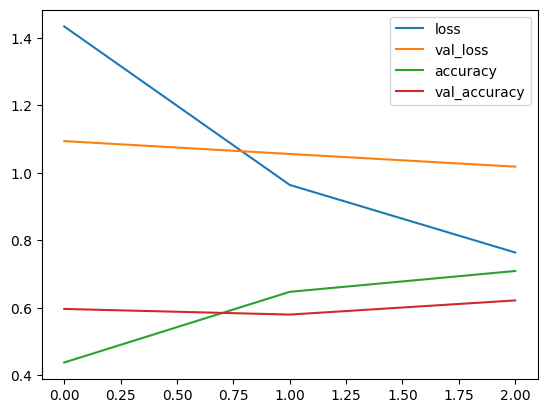

In [8]:
import matplotlib.pyplot as plt

plt.plot(r.history['loss'])
plt.plot(r.history['val_loss'])
plt.plot(r.history['accuracy'])
plt.plot(r.history['val_accuracy'])
plt.legend(['loss', 'val_loss', 'accuracy', 'val_accuracy'])
plt.show()